In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [155]:
url = '/Users/tanmay/Desktop/Visual Studio Stuff/datasets/learning datasets/IPL Dataset/matches.csv'
df = pd.read_csv(url)
df

,id,season,city,date,match_type,player_of_match,venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,target_runs,target_overs,super_over,method,umpire1,umpire2
0,335982,2007/08,Bangalore,2008-04-18,League,BB McCullum,M Chinnaswamy Stadium,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,field,Kolkata Knight Riders,runs,140.0,223.0,20.0,N,NaN,Asad Rauf,RE Koertzen
1,335983,2007/08,Chandigarh,2008-04-19,League,MEK Hussey,"Punjab Cricket Association Stadium, Mohali",Kings XI Punjab,Chennai Super Kings,Chennai Super Kings,bat,Chennai Super Kings,runs,33.0,241.0,20.0,N,NaN,MR Benson,SL Shastri
2,335984,2007/08,Delhi,2008-04-19,League,MF Maharoof,Feroz Shah Kotla,Delhi Daredevils,Rajasthan Royals,Rajasthan Royals,bat,Delhi Daredevils,wickets,9.0,130.0,20.0,N,NaN,Aleem Dar,GA Pratapkumar
3,335985,2007/08,Mumbai,2008-04-20,League,MV Boucher,Wankhede Stadium,Mumbai Indians,Royal Challengers Bangalore,Mumbai Indians,bat,Royal Challengers Bangalore,wickets,5.0,166.0,20.0,N,NaN,SJ Davis,DJ Harper
4,335986,2007/08,Kolkata,2008-04-20,League,DJ Hussey,Eden Gardens,Kolkata Knight Riders,Deccan Chargers,Deccan Chargers,bat,Kolkata Knight Riders,wickets,5.0,111.0,20.0,N,NaN,BF Bowden,K Hariharan
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1090,1426307,2024,Hyderabad,2024-05-19,League,Abhishek Sharma,"Rajiv Gandhi International Stadium, Uppal, Hyd...",Punjab Kings,Sunrisers Hyderabad,Punjab Kings,bat,Sunrisers Hyderabad,wickets,4.0,215.0,20.0,N,NaN,Nitin Menon,VK Sharma
1091,1426309,2024,Ahmedabad,2024-05-21,Qualifier 1,MA Starc,"Narendra Modi Stadium, Ahmedabad",Sunrisers Hyderabad,Kolkata Knight Riders,Sunrisers Hyderabad,bat,Kolkata Knight Riders,wickets,8.0,160.0,20.0,N,NaN,AK Chaudhary,R Pandit
1092,1426310,2024,Ahmedabad,2024-05-22,Eliminator,R Ashwin,"Narendra Modi Stadium, Ahmedabad",Royal Challengers Bengaluru,Rajasthan Royals,Rajasthan Royals,field,Rajasthan Royals,wickets,4.0,173.0,20.0,N,NaN,KN Ananthapadmanabhan,MV Saidharshan Kumar
1093,1426311,2024,Chennai,2024-05-24,Qualifier 2,Shahbaz Ahmed,"MA Chidambaram Stadium, Chepauk, Chennai",Sunrisers Hyderabad,Rajasthan Royals,Rajasthan Royals,field,Sunrisers Hyderabad,runs,36.0,176.0,20.0,N,NaN,Nitin Menon,VK Sharma


In [156]:
print(df.shape)
print(df.columns)

(1095, 20)
Index(['id', 'season', 'city', 'date', 'match_type', 'player_of_match',
       'venue', 'team1', 'team2', 'toss_winner', 'toss_decision', 'winner',
       'result', 'result_margin', 'target_runs', 'target_overs', 'super_over',
       'method', 'umpire1', 'umpire2'],
      dtype='object')


In [157]:
print(df.isnull().sum())
df.dtypes

id                    0
season                0
city                 51
date                  0
match_type            0
player_of_match       5
venue                 0
team1                 0
team2                 0
toss_winner           0
toss_decision         0
winner                5
result                0
result_margin        19
target_runs           3
target_overs          3
super_over            0
method             1074
umpire1               0
umpire2               0
dtype: int64


id                   int64
season              object
city                object
date                object
match_type          object
player_of_match     object
venue               object
team1               object
team2               object
toss_winner         object
toss_decision       object
winner              object
result              object
result_margin      float64
target_runs        float64
target_overs       float64
super_over          object
method              object
umpire1             object
umpire2             object
dtype: object

In [158]:
# Create some columns
df['toss_winner_is_team1'] = (df['toss_winner'] == df['team1']).astype(int)
df['team1_won'] = (df['winner'] == df['team1']).astype(int)

# Drop abandoned/tie matches
df = df.drop(axis=0, index=df[df['winner'].isnull()].index)
df = df.drop(axis=0, index=df[df['result'] == 'tie'].index)

# Drop unnecessary columns
df = df.drop(['id', 'date', 'player_of_match', 'umpire1', 'umpire2', 'result'], axis=1)
df = df.drop('super_over', axis=1)
df = df.drop('toss_winner', axis=1)
df = df.drop('winner', axis=1)

# Map the elements
df['city'] = df['city'].fillna(df['city'].mode()[0])
df['method'] = (df['method'] == 'D/L').astype(int)
df['toss_decision'] = df['toss_decision'].map({ 'field': 0, 'bat': 1 })

df['season'] = df['season'].astype(str).str[:4].astype(int) # to convert seasons like 2009/10 to just 2009

In [159]:
from sklearn.preprocessing import LabelEncoder

for col in ['team1', 'team2', 'venue', 'city', 'match_type']:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])

In [160]:
df

,season,city,match_type,venue,team1,team2,toss_decision,result_margin,target_runs,target_overs,method,toss_winner_is_team1,team1_won
0,2007,2,4,23,16,8,0,140.0,223.0,20.0,0,1,0
1,2007,7,4,40,6,0,1,33.0,241.0,20.0,0,0,0
2,2007,10,4,16,3,13,1,9.0,130.0,20.0,0,0,1
3,2007,26,4,55,10,16,1,5.0,166.0,20.0,0,1,0
4,2007,23,4,14,8,1,1,5.0,111.0,20.0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1090,2024,16,4,43,12,18,1,4.0,215.0,20.0,0,1,0
1091,2024,1,5,32,18,8,1,8.0,160.0,20.0,0,1,0
1092,2024,1,2,32,17,13,0,4.0,173.0,20.0,0,0,0
1093,2024,8,6,28,18,13,0,36.0,176.0,20.0,0,0,1


In [138]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.metrics import accuracy_score, classification_report

In [139]:
models = {
    'Logistic Regression': (LogisticRegression(random_state=42), True),
    'KNN': (KNeighborsClassifier(n_neighbors=7), True),
    'Decision Tree': (DecisionTreeClassifier(max_depth=4, random_state=42), False),
    'Random Forest': (RandomForestClassifier(n_estimators=200, max_depth=8, random_state=42, n_jobs=-1), False),
    'SVM': (SVC(kernel='rbf', C=10, gamma=0.1, random_state=42), True)
}

In [150]:
df = df.drop(['result_margin', 'target_runs', 'target_overs'], axis=1)
X = df.drop('team1_won', axis=1)
y = df['team1_won']

In [151]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [152]:
# Scaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [153]:
print(f"{'Model':<25} {'Train':>8} {'Test':>8}")
print("-" * 45)

for name, (m, needs_scaling) in models.items():
    if needs_scaling:
        m.fit(X_train_scaled, y_train)
        train_score = m.score(X_train_scaled, y_train)
        test_score  = m.score(X_test_scaled, y_test)
    else:
        m.fit(X_train, y_train)
        train_score = m.score(X_train, y_train)
        test_score  = m.score(X_test, y_test)

    print(f"{name:<25} {train_score:>8.3f} {test_score:>8.3f}")

Model                        Train     Test
---------------------------------------------
Logistic Regression          0.530    0.491
KNN                          0.672    0.486
Decision Tree                0.559    0.491
Random Forest                0.853    0.468
SVM                          0.702    0.495


In [ ]:
# every model on testing gave out < 50% accuracy
# so the features which we have aren't enough to predict who will win the cricket match

# Unfortunately, the model first performed quite well (85% accuracy) but that was because of data leakage
# So when i tried it again after data leak, the accuracy plummeted to just below 50%

In [147]:
# Random Forest won so let's tune it now
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [6, 8, 10, None],
    'min_samples_split': [5, 10, 15]
}

grid = GridSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train, y_train)
print(f"Best Params:  {grid.best_params_}")
print(f"Best CV Score:  {grid.best_score_:.3f}")
print(f"Test Score:  {grid.best_estimator_.score(X_test, y_test):.3f}")

Fitting 5 folds for each of 36 candidates, totalling 180 fits
Best Params:  {'max_depth': None, 'min_samples_split': 5, 'n_estimators': 300}
Best CV Score:  0.814
Test Score:  0.838


In [148]:
# Random Forest won so let's tune it now
param_grid = {
    'n_estimators': [200, 300, 500],
    'max_depth': [8, 10, 12, 15, 20],
    'min_samples_split': [5, 10, 15],
    'min_samples_leaf': [2, 4, 6]
}

grid = GridSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train, y_train)
print(f"Best Params:  {grid.best_params_}")
print(f"Best CV Score:  {grid.best_score_:.3f}")
print(f"Test Score:  {grid.best_estimator_.score(X_test, y_test):.3f}")

Fitting 5 folds for each of 135 candidates, totalling 675 fits
Best Params:  {'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 10, 'n_estimators': 500}
Best CV Score:  0.808
Test Score:  0.852


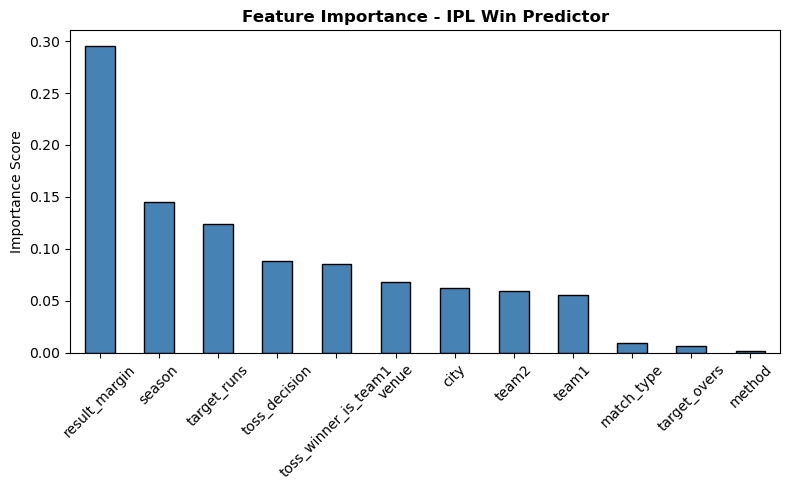

In [149]:
# Feature Importance
best_model = grid.best_estimator_

importance = pd.Series(
    best_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

plt.figure(figsize=(8, 5))
importance.plot(kind='bar', color='steelblue', edgecolor='black')
plt.title("Feature Importance - IPL Win Predictor", fontweight='bold')
plt.ylabel("Importance Score")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()